In [4]:
# Load lib and set up environment
from pathlib import Path
import sys
import pandas as pd
from AlphaBase import AlphaBase
root = Path.cwd().parent
sys.path.append(str(root))


# Call the alpha
alpha = AlphaBase()


# Load Data
data_list = alpha.generate_data() # -> a list of data dict organized as "data_name": <tabular ohlcv>
vnf1m = data_list['Vn30F1MR_5m'] # -> call the data you mentioned in cfg
vn = data_list['vn30_5m']

# Play around with your data
vnmerge = vnf1m.merge(
    vn,
    on='datetime',
    how='left',
    suffixes=('', '_vn30')
)

cols = ['open', 'high', 'low', 'close', 'volume']

for col in cols:
    vnmerge[f'{col}_vn30'] = vnmerge[f'{col}_vn30'].ffill()


[WARNING] Trading View's limit on INTRADAY DATA for VN30 can cause unexpected error! 
[WARNING] Trading View's limit on INTRADAY DATA for VN30F1M can cause unexpected error! 
[CACHE] Loaded TY_GIA_1d sucessfully
[CACHE] Loaded VN30F1MR_5m sucessfully
[CACHE] Loaded VN30F1M_5m sucessfully
[CACHE] Loaded VN30_5m sucessfully
[CACHE] Loaded ETHUSDT_10m sucessfully

Successfully scraped 5/5 symbol


In [ ]:
# We use optuna for Technical_Analysis_styled alpha

param_range = {
    "gap_lb": (5, 260), # name of params must match that in config file
    "vol_lb": (5, 260),  # for int: low=5, high=260, step=1 (default step)
    "vol_size": (5.0, 7.0, 0.5), # for float: low, high, step=0.5 (if step not mention, each step would be very small)
    "w_gap": ["True", "False"], # for bool and category param, a list of choices is used.
    "w_vol": ['high', 'low', 'medium']   
}

In [ ]:
# Train the alpha
"""
data: vnmerge
param range for tuning: param_range
opt_metric: sharpe, mdd, return, ... -> we can custom function by doing: "sharpe*return", "sharpe**2", "mdd/sharpe"
n_trials: number of trials -> early stop is default to 700
n_fold: folds to walk forward split the data and train
oos_ratio: a portion of data taken out at the very first to use as OOS test data in the end
"""
alpha.train(vnmerge, param_range=param_range, opt_metric="sharpe*mdd/2*return**2", n_trials=2500, n_fold=5, oos_ratio=0.15)

AFTER OPTUNA PLEASE RUN CELL 1 AGAIN TO SEE RESULT AFTER OPTIMIZATION
 ========== Financial Backtest Vietnam Future ==========
 
IN SAMPLE PERFORMANCE

    Initial capital: 260,000,000.00
     Ending capital: -886,495,789.01
             Sharpe: -7.05
            Sortino: -9.45
             Calmar: -0.14
                MDD: 1,147,499,362.52 (441.35%); Time: 2018-01-02 09:00:00 -> 2023-12-06 14:10:00
       Total Profit: -1,146,495,789.01
   Margin per Trade: -4.03 bps
       Total Return: -371.56%
 Mean Annual Return: -63.09%
Comp. Annual Return: nan%
       Hitrate Long: 4.87%
      Hitrate Short: 8.20%
      Total Hitrate: 6.82%
        Longest Win: 7 days
       Longest Loss: 24 days
      Trade per Day: 3.55
        Long Trades: 2255
       Short Trades: 3017



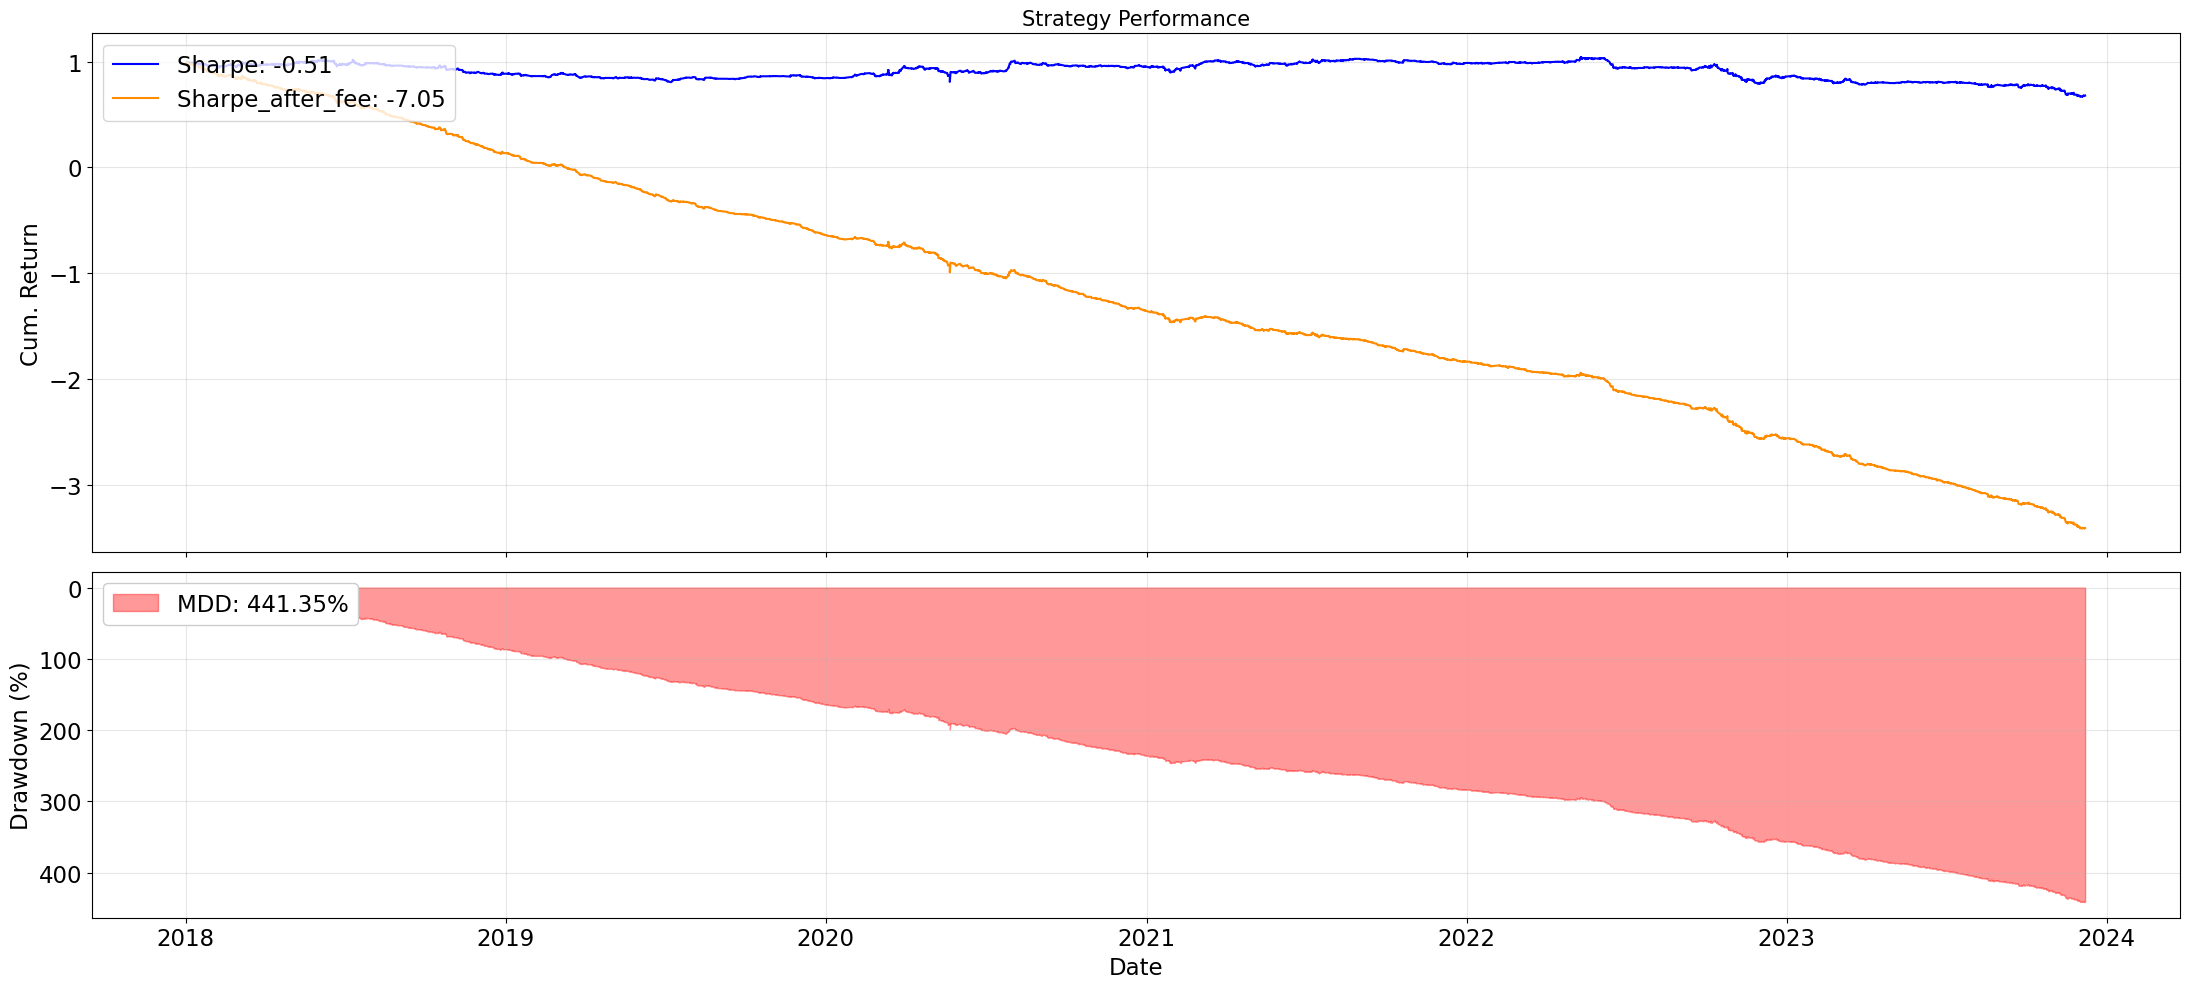

 
OUT SAMPLE PERFORMANCE

    Initial capital: 260,000,000.00
     Ending capital: 58,464,490.13
             Sharpe: -12.11
            Sortino: -15.66
             Calmar: -1.07
                MDD: 203,108,240.75 (78.12%); Time: 2023-12-12 09:00:00 -> 2024-12-31 14:30:00
       Total Profit: -201,535,509.87
   Margin per Trade: -3.91 bps
       Total Return: -87.17%
 Mean Annual Return: -83.85%
Comp. Annual Return: -86.13%
       Hitrate Long: 7.18%
      Hitrate Short: 10.72%
      Total Hitrate: 9.22%
        Longest Win: 4 days
       Longest Loss: 24 days
      Trade per Day: 3.80
        Long Trades: 441
       Short Trades: 555



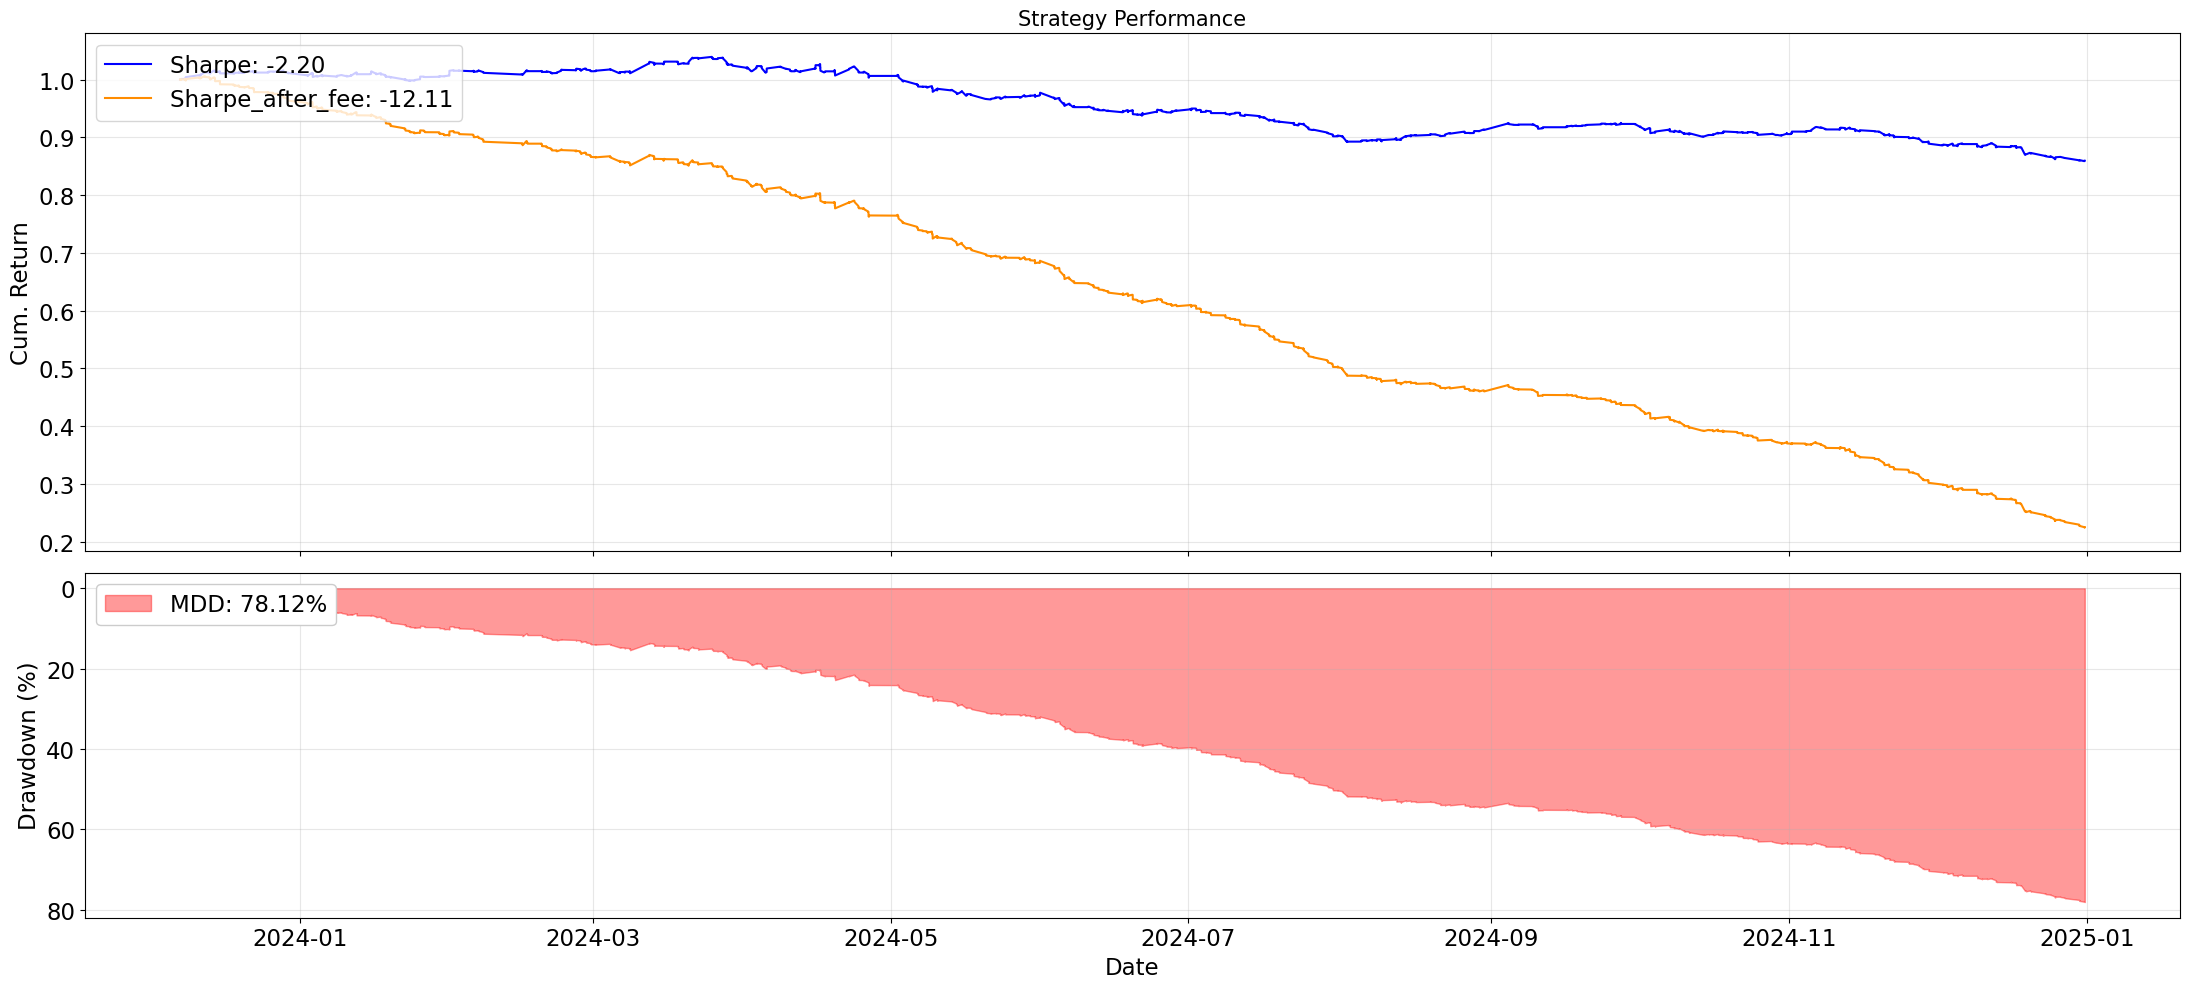

 
ALL DATA PERFORMANCE

    Initial capital: 260,000,000.00
     Ending capital: -1,089,147,158.71
             Sharpe: -7.43
            Sortino: -9.95
             Calmar: -0.12
                MDD: 1,349,223,680.45 (518.93%); Time: 2018-01-02 09:00:00 -> 2024-12-31 14:30:00
       Total Profit: -1,349,147,158.71
   Margin per Trade: -4.01 bps
       Total Return: -448.62%
 Mean Annual Return: -64.79%
Comp. Annual Return: nan%
       Hitrate Long: 5.25%
      Hitrate Short: 8.61%
      Total Hitrate: 7.21%
        Longest Win: 7 days
       Longest Loss: 24 days
      Trade per Day: 3.59
        Long Trades: 2699
       Short Trades: 3572



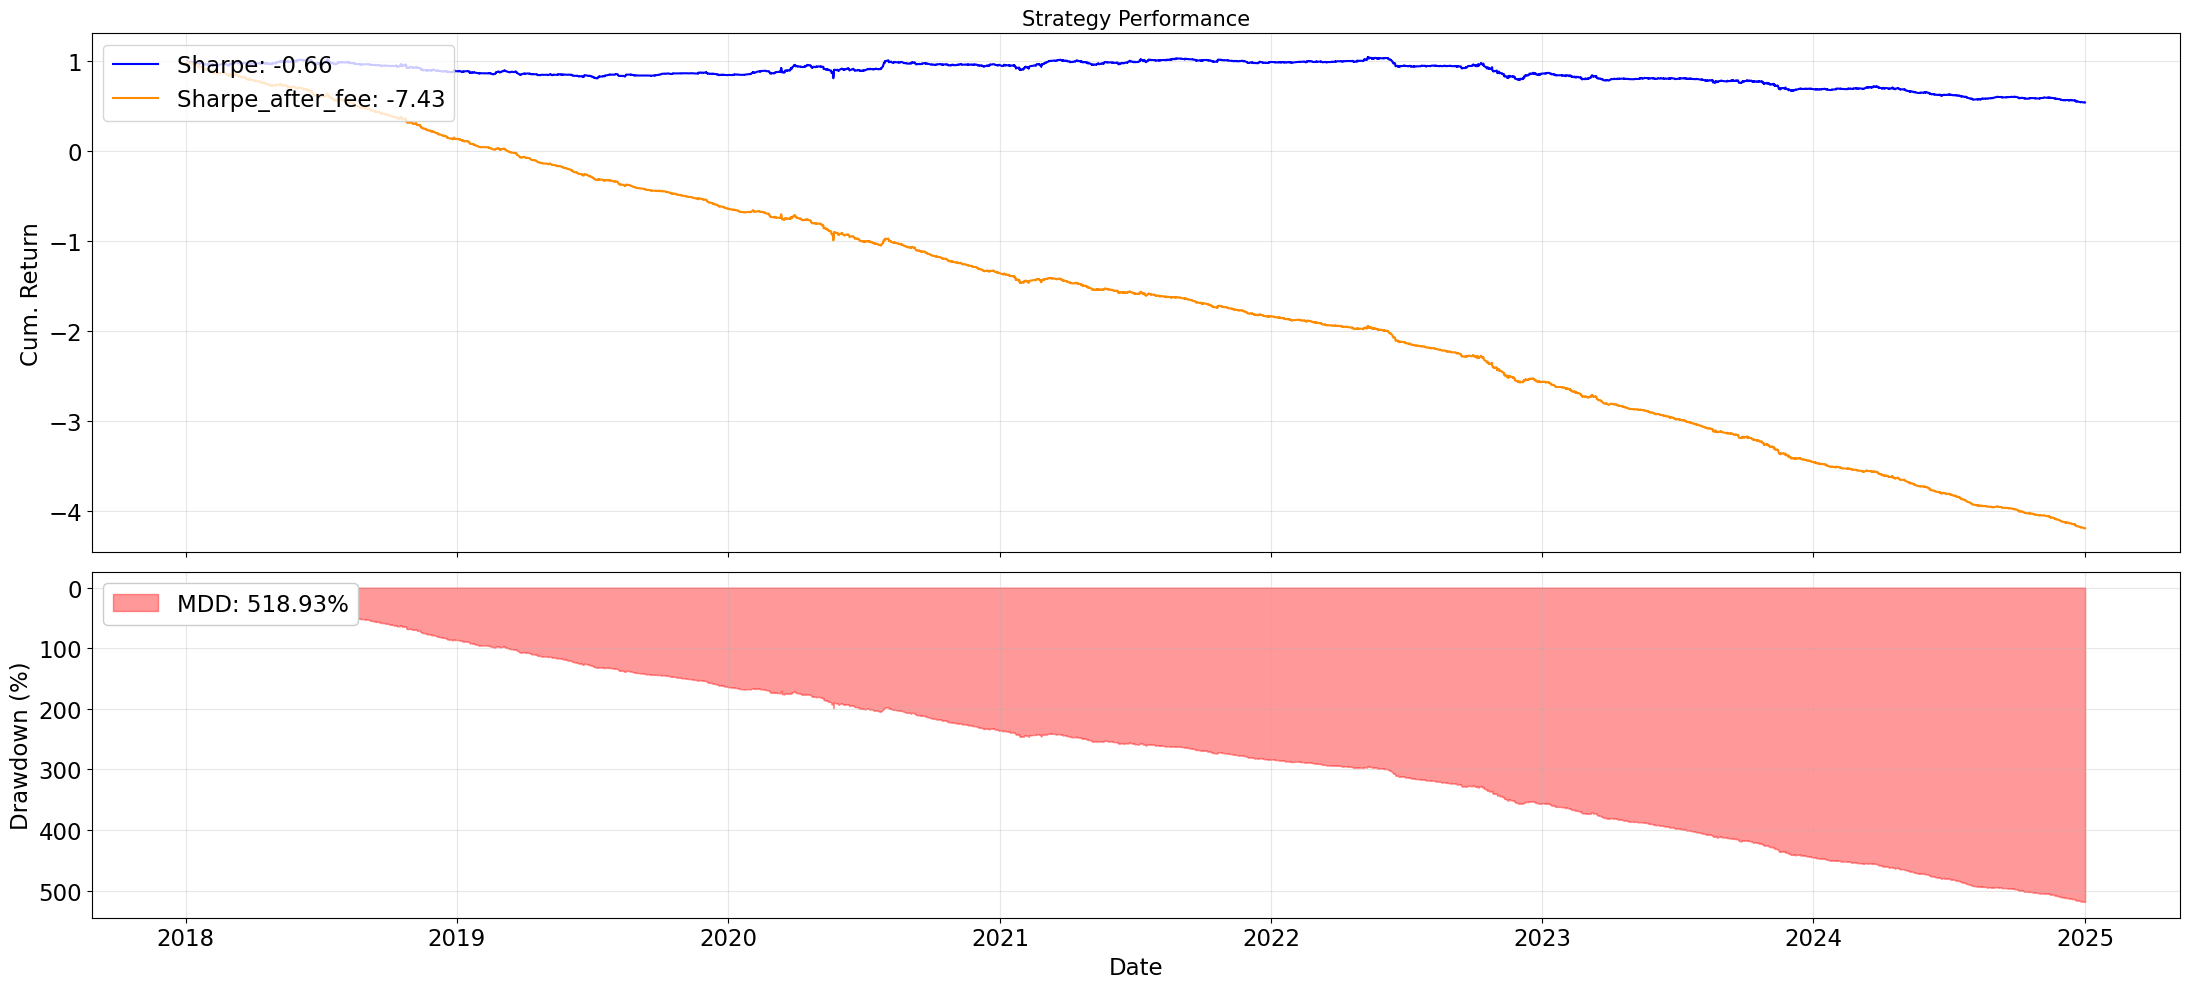

 ========== Alpha Robustness Test Vietnam Future ==========
Pass future leak test.
Fail overfit test because Sharpe too low


In [5]:
RED = "\033[31m"
RESET = "\033[0m"
print(f"{RED}AFTER OPTUNA PLEASE RUN CELL 1 AGAIN TO SEE RESULT AFTER OPTIMIZATION{RESET}")

# Print out backtest info
# data and oos_ratio is provided
# The function return results for financial and statistical backtest
alpha.backtest(vnmerge, oos_ratio=0.15)